In [16]:
import pandas as pd 
import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.1f}'.format


In [23]:
def remove_outliers(dataset, groupby, var_to_compute):
      
        grouped = dataset.groupby(by=groupby)[var_to_compute]

        q1 = grouped.transform('quantile' , 0.25)
        q3 = grouped.transform('quantile' , 0.75)

        iqr = q3 - q1 

        lower_bound  = q1 - 1.5 * iqr 
        upper_bound = q3 + 1.5 * iqr 

        mask = ( ( dataset[var_to_compute] <= lower_bound ) & ( dataset[var_to_compute] >= upper_bound )  )

        return dataset[mask]

In [18]:

def stats( dataset , groupby: str , var_to_compute : str ,  statistics=None):
    
    if statistics == None :
        statistics = ['count' , 'min' , 'max' , 'median' , 'mean' , 'std']
    
    statis_data = dataset.groupby(groupby)[var_to_compute].agg(
        statistics
    )
    statis_data['cv'] = statis_data['std'] / statis_data['mean']
    statis_data['cv_%'] = statis_data['std'] / statis_data['mean'] * 100
    
    return statis_data


In [19]:
def scaling():
    pass

In [20]:
df_cpu = pd.read_csv("result_cpu.csv")
df_gpu = pd.read_csv("result_gpu.csv")



### Check the Outliers

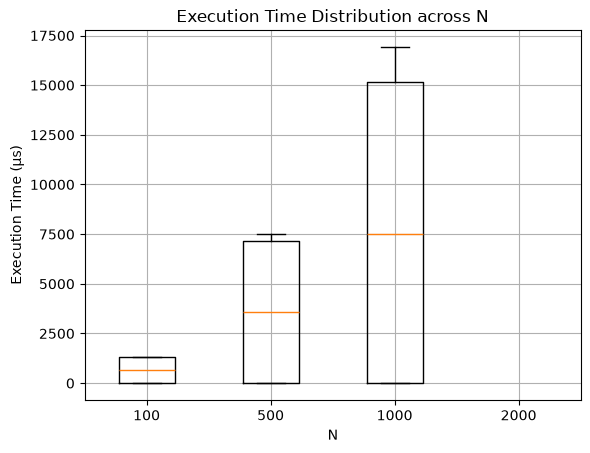

In [21]:
# plt.boxplot([df_cpu[df_cpu['N'] == n]['time_us'] for n in [100, 500, 1000, 2000]], 
#             tick_labels=[100, 500, 1000, 2000],
#             )
plt.boxplot([df_gpu[df_gpu['N'] == n]['time_us'] for n in [100, 500, 1000, 2000]], 
            tick_labels=[100, 500, 1000, 2000],
            )
            
plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time Distribution across N")
plt.grid(True)
plt.show()

### Remove the Outliers Using IQR :

In [24]:
groupby = "N"
var_to_compute = "time_us" 

clean_data_cpu = remove_outliers(df_cpu , groupby , var_to_compute )
clean_data_gpu = remove_outliers(df_gpu , groupby , var_to_compute )

print(f"Original Samples : {len(df_cpu)}" )
print(f"Clean Samples : {len(clean_data_cpu)}")

removed_percentages = ( len(df_cpu) - len(clean_data_cpu)  ) / len(clean_data_cpu) * 100

print(f"Removed         : {removed_percentages:.2f} %")

Original Samples : 80
Clean Samples : 18
Removed         : 344.44 %


In [ ]:
original_count = df.groupby('N').size()
clean_count = clean_data.groupby('N').size()

outlier_stats = pd.DataFrame({
    'original': original_count,
    'clean': clean_count
})

outlier_stats['removed'] = (
    outlier_stats['original'] -
    outlier_stats['clean']
)

outlier_stats['removed_%'] = (
    outlier_stats['removed'] /
    outlier_stats['original'] * 100
)

outlier_stats


### Statistics


In [ ]:
groupby = "N"
var_to_compute = "time_us" 
stats_data =  stats( clean_data , groupby, var_to_compute)
stats_data

In [ ]:
# median_execution_time():

plt.plot(stats_data['N'], stats_data['median'], color='green', marker='o', label='median')
plt.plot(stats_data['N'], stats_data['mean'], color='red', linestyle='--', label='mean')

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time (µs)")
plt.grid(True)
plt.legend() 
plt.show()

In [ ]:
# execution_time_log():
plt.errorbar(
    stats_data['N'],
    stats_data['mean'],
    yerr=stats_data['std'],
    fmt='-',
    capsize=5
)

plt.scatter(
    stats_data['N'],
    stats_data['mean'],
    color='red',
    zorder=3
)

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Execution time (µs)")
plt.title("Execution Time vs N (Log Scale)")
plt.grid(True)

plt.show()